In [2]:
#%%
import math
import numpy as np
import inspect
import importlib

import scipy.interpolate

import importlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules import *

path_to_save_svg = "Saved_Data"

dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())


Importing IoT Node models
Importing IoT Node Energy models
Importing IoT Node Energy models
Importing Wireless communication packages
Importing Wireless communication packages
Importing custom modules data
Importing custom modules data


In [3]:
V=0.8

In [4]:
I_Sleep_0V8  = 0.0
I_TX_0V8     = 40
I_RX_0V8_low     = 0.88
I_RX_0V8_high    = 2.72
lna_module_0V8 = Node_module(name="LNA",
                            v=0.8,
                            i_sleep=I_Sleep_0V8)
lna_state_TX_0V8 = Module_state("TX",i = I_TX_0V8,duration = None)
lna_state_RX_0V8 = Module_state("RX",i = I_RX_0V8_low, duration = None)
lna_module_0V8.add_state(lna_state_TX_0V8)
lna_module_0V8.add_state(lna_state_RX_0V8)

In [5]:
fs = 125e3*16 
b  = 12
fb =560e6
P_ADC = (0.67*10**(-15)) * (2**b) * fs * np.sqrt(1 + (fs/fb)**2 )
print(P_ADC)
print( 2*1000*P_ADC)
I_adc = 2*1000*P_ADC
print(2*1000*(0.67*10**(-15))*fs*(2**b))

I_adc_Sleep_0V8  = 0.0
I_adc_TX_0V8     = I_adc
I_adc_RX_0V8     = I_adc
adc_module_0V8 = Node_module(name="ADC",
                            v=0.8,
                            i_sleep=I_adc_Sleep_0V8)
adc_state_TX_0V8 = Module_state("TX",i = I_adc_TX_0V8,duration = None)
adc_state_RX_0V8 = Module_state("RX",i = I_adc_RX_0V8,duration = None)
adc_module_0V8.add_state(adc_state_TX_0V8)
adc_module_0V8.add_state(adc_state_RX_0V8)

substask_ADC_Proc    = Node_subtask(name='ADC ' ,module=adc_module_0V8 , moduleState = adc_state_RX_0V8, stateDuration=0.02)

5.488675003970015e-06
0.010977350007940031
0.010977280000000002


In [6]:
I_mix_Sleep_0V8  = 0.0
I_mix_TX_0V8     = 0.281 *2
I_mix_RX_0V8     = 0.281 *2
mix_module_0V8 = Node_module(name="2-Mixers",
                            v=0.8,
                            i_sleep=I_mix_Sleep_0V8)
mix_state_TX_0V8 = Module_state("TX",i = I_mix_TX_0V8,duration = None)
mix_state_RX_0V8 = Module_state("RX",i = I_mix_RX_0V8,duration = None)
mix_module_0V8.add_state(mix_state_TX_0V8)
mix_module_0V8.add_state(mix_state_RX_0V8)

substask_mix_Proc_TX    = Node_subtask(name='Mixers TX ' ,module=mix_module_0V8 , moduleState = mix_state_TX_0V8, stateDuration=0.03)
substask_mix_Proc_RX    = Node_subtask(name='Mixers RX ' ,module=mix_module_0V8 , moduleState = mix_state_RX_0V8, stateDuration=0.03)

In [7]:
I_pll_Sleep_0V8  = 0.0
I_pll_TX_0V8     = 0.370
I_pll_RX_0V8     = 0.370
pll_module_0V8 = Node_module(name="PLL",
                            v=0.8,
                            i_sleep=I_pll_Sleep_0V8)
pll_state_TX_0V8 = Module_state("TX",i = I_pll_TX_0V8,duration = None)
pll_state_RX_0V8 = Module_state("RX",i = I_pll_RX_0V8,duration = None)
pll_module_0V8.add_state(pll_state_TX_0V8)
pll_module_0V8.add_state(pll_state_RX_0V8)

substask_pll_Proc_TX    = Node_subtask(name='PLL TX ' ,module=pll_module_0V8 , moduleState = pll_state_TX_0V8, stateDuration=0.03)
substask_pll_Proc_RX    = Node_subtask(name='PLL RX ' ,module=pll_module_0V8 , moduleState = pll_state_RX_0V8, stateDuration=0.03)

In [8]:
I_tsp_Sleep_0V8  = 0.0
I_tsp_TX_0V8     = 0.316
I_tsp_RX_0V8     = 0.316
tsp_module_0V8 = Node_module(name="TSP",
                            v=0.8,
                            i_sleep=I_tsp_Sleep_0V8)
tsp_state_TX_0V8 = Module_state("TX",i = I_tsp_TX_0V8,duration = None)
tsp_state_RX_0V8 = Module_state("RX",i = I_tsp_RX_0V8,duration = None)
tsp_module_0V8.add_state(tsp_state_TX_0V8)
tsp_module_0V8.add_state(tsp_state_RX_0V8)

substask_TSP_Proc_TX    = Node_subtask(name='TSP TX ' ,module=tsp_module_0V8 , moduleState = tsp_state_TX_0V8, stateDuration=0.03)
substask_TSP_Proc_RX    = Node_subtask(name='TSP RX ' ,module=tsp_module_0V8 , moduleState = tsp_state_RX_0V8, stateDuration=0.03)

In [9]:
this_module_list = [lna_module_0V8,pll_module_0V8,mix_module_0V8,adc_module_0V8,tsp_module_0V8]

node_LDO = LDO(name = "Node LDO", v_out = 0.8, i_q = 1e-3, v_in = 0.8, module_list = this_module_list)
node_Batt= Battery(name = "Node Batt.", v = 0.8, capacity_mAh = 1800, i = 0, selfdischarge_p_year = 5)

node_lora = LoRa_Node(name= "IoT Node", module_list= this_module_list, PMU_composition =[node_LDO], Battery = node_Batt,  radio_module = lna_module_0V8)

node= LoRa_Node_profile("Node_profile", node_lora, 
                        Proc_subtask_tx = [substask_TSP_Proc_TX ],
                        Proc_subtask_rx = [substask_TSP_Proc_RX, substask_ADC_Proc,substask_mix_Proc_RX,substask_pll_Proc_RX], 
                        RX_state=lna_state_RX_0V8,TX_state=lna_state_TX_0V8,
                    P_TX= PTX_PABOOST_configured, I_TX=I_PABoost_3V3 )

time = 24*60*60/(len(this_module_list))
#tx_node   = node.create_task_tx(name="TX-0", Ptx = 17,SF=9 ,Coding=1,Header=True,DE = 1,BW = 125e3, Payload = 50, TX_rate=24*1)
rx_beacon = node.create_task_rx(name="Beacon", RX_rate=1, RX_duration=time) #0.16  ) #27 symbols
#rx_ping   = node.create_task_rx(name="Ping"  , RX_rate=1, RX_duration=0.032) #0.032 )

substask_TSP_Proc_RX.set_stateDuration(time)
substask_ADC_Proc.set_stateDuration(time)
substask_mix_Proc_RX.set_stateDuration(time)
substask_pll_Proc_RX.set_stateDuration(time)
#node.change_task_rate(tx_node     ,0)
node.change_task_rate(rx_beacon   ,1)#/128)
#node.change_task_rate(rx_ping     ,24*60*60/32)#/32)

#node.add_task(task_TPHG_0V8,24*12)

In [10]:
#def PL_model(d):
#    return path_loss_PLd0(d=d, PLd0=94.40,d0=1, n=2.03)
#
#tx_node.set_Path_loss_model(PL_model)

In [11]:
figsize = (6,5)

-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          Beacon         
Times/day    [1/d]   : 1              1              
Tot. durat.  [s]     : 0.0000         86400.0000     
Tot. en./d   [mJ]    : 0.0000         29569.2229     
Node en./d   [mJ]    : 29569.2229      
Average pow. [mW]    : 0.3422          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ]  Av. Cur.[uA]  
LNA                       17280.0000   12165.1200   176.0000000   
     -       Sleep        69120.0000   0.0000       
     -       TX           0.0000       0.0000       
     -       RX           17280.0000   12165.1200   
PLL          

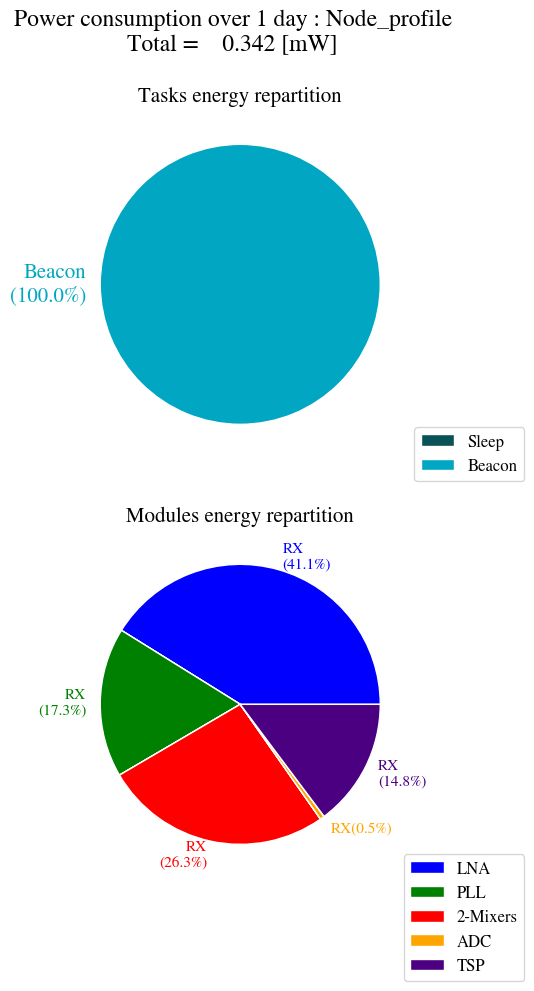

In [12]:
lna_state_RX_0V8.set_i(I_RX_0V8_low)
node.compute()
node.print_Tasks()
node.print_Modules()
node.plot_Power()


In [13]:
pow_module_low = np.zeros((len(this_module_list)))
for i,mod in enumerate(this_module_list):
    pow_module_low[i] = mod.get_average_power()*(24*60*60)/time
print(pow_module_low)

[0.704      0.296      0.4496     0.00878188 0.2528    ]


-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          Beacon         
Times/day    [1/d]   : 1              1              
Tot. durat.  [s]     : 0.0000         86400.0000     
Tot. en./d   [mJ]    : 0.0000         55005.3829     
Node en./d   [mJ]    : 55005.3829      
Average pow. [mW]    : 0.6366          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ]  Av. Cur.[uA]  
LNA                       17280.0000   37601.2800   544.0000000   
     -       Sleep        69120.0000   0.0000       
     -       TX           0.0000       0.0000       
     -       RX           17280.0000   37601.2800   
PLL          

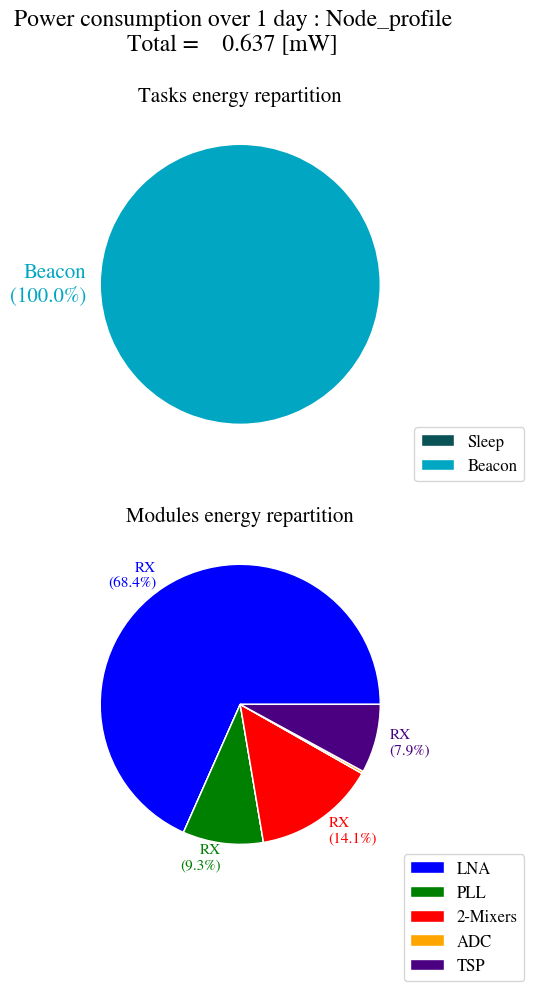

In [14]:
lna_state_RX_0V8.set_i(I_RX_0V8_high)
node.compute()
node.print_Tasks()
node.print_Modules()
node.plot_Power()



In [15]:
pow_module_high = np.zeros((len(this_module_list)))
for i,mod in enumerate(this_module_list):
    pow_module_high[i] = mod.get_average_power()*(24*60*60)/time
print(pow_module_high)

[2.176      0.296      0.4496     0.00878188 0.2528    ]


In [16]:
print(pow_module_high)
print(pow_module_low)
pow_high = np.sum(pow_module_high)
pow_low  = np.sum(pow_module_low)
print(pow_high)
print(pow_low)
print()
print(pow_module_high/pow_high)
print(pow_module_low /pow_low)
print()
print(100*pow_low/pow_high)
print(100*(1-pow_low/pow_high))

[2.176      0.296      0.4496     0.00878188 0.2528    ]
[0.704      0.296      0.4496     0.00878188 0.2528    ]
3.183181880006353
1.7111818800063523

[0.68359273 0.09298872 0.14124232 0.00275884 0.07941739]
[0.41141156 0.17297986 0.26274238 0.00513206 0.14773415]

53.75696220044257
46.24303779955743


In [19]:
fs = 125e3 * 16
b  = 12
fb =560e6
fom_walden = (0.67*10**(-15))* np.sqrt(1 + (fs/fb)**2 )
P_ADC = fom_walden * (2**b) * fs 
print(P_ADC)
print(fom_walden)
P_ADCs = 2*P_ADC*1000
print(P_ADCs)

P_Mixers = 2*0.281
P_PLL   =    0.370
P_TSP   =    0.316
P_LNA_l =    0.88
P_LNA_h =    2.72

5.488675003970015e-06
6.700042729455585e-16
0.010977350007940031


: 

In [40]:
figsize  = (4,8)
barWidth = 0.9
fontsize= 20


import matplotlib
plt.rcParams["font.family"] =  'Segoe UI'
matplotlib.rcParams.update({'font.size': fontsize})
matplotlib.rcParams['lines.linewidth'] = 5
matplotlib.rcParams['xtick.major.size'] = 5
matplotlib.rcParams['xtick.major.width'] = 2
matplotlib.rcParams['ytick.major.size'] = 5
matplotlib.rcParams['ytick.major.width'] = 2
matplotlib.rc('axes', linewidth=2)


Mixers
14%
Mixers
26%
PLL 9.3%
PLL 17%
DBB 7.9%
DBB 14%
ADCs 0.3%
ADCs 0.5%
0.4624303779955743
3.9789773500079404


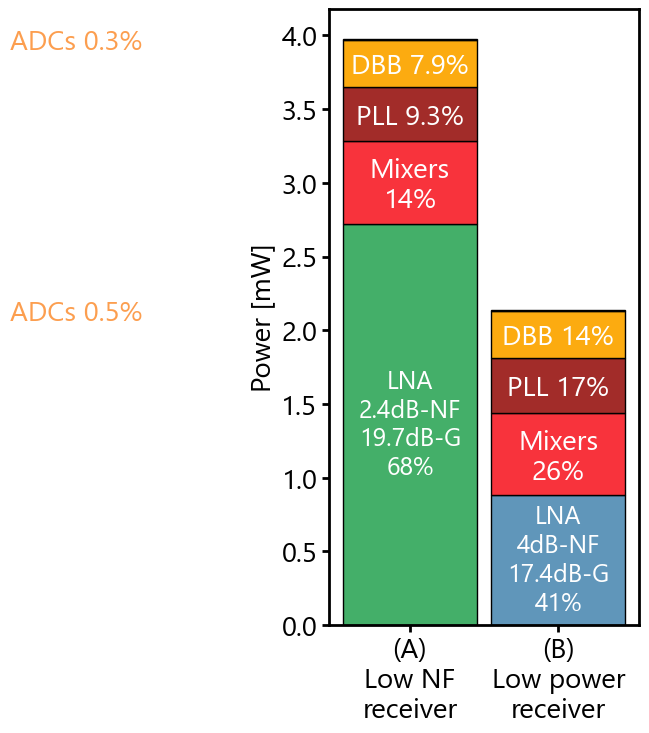

In [52]:
P_noRFFE = P_PLL+ P_Mixers+P_ADCs+P_TSP
P_tot_l  = P_noRFFE +P_LNA_l
P_tot_h  = P_noRFFE +P_LNA_h
P_LNA   =  np.array([P_LNA_h,P_LNA_l])
P_tot   =  np.array([P_tot_h,P_tot_l])
xlabel =   ["LNA ", "Mixers","PLL","DBB",'ADCs']
Power_h  = np.array([P_LNA_h,P_Mixers,P_PLL,P_TSP,P_ADCs])
Power_l  = np.array([P_LNA_l,P_Mixers,P_PLL,P_TSP,P_ADCs])

Power    = np.array([Power_h,Power_l])

offset = 0.02

color_offset = 4
colors_bar_h =   listColor[color_offset: color_offset+len(Power_h)]
colors_bar_l =  listColor[color_offset+1: color_offset+len(Power_h)]
colors_bar_l.insert(0,listColor[color_offset-1])

Second_bars   = np.zeros((len(Power_h)))
Second_bars[0]= P_LNA_l

fig,ax = plt.subplots(1,1,figsize=figsize)

LNA_labels = ["LNA\n2.4dB-NF\n19.7dB-G", "LNA\n4dB-NF\n17.4dB-G"]

oneline = [0,0,1,1,1]
notPlot = [0,0,0,0,1]

bars = ax.bar(x= [0,1]   ,
        height = [P_LNA_h,P_LNA_l], width =barWidth,edgecolor = "black", color=[listColor[color_offset], listColor[color_offset-1]])
for j in range(2):
        toDisplay = LNA_labels[j]+"\n"+"%i"%(np.round(100*P_LNA[j]/P_tot[j]))+"%"
        plt.text( bars[j].get_x() +  bars[j].get_width()*0.5, P_LNA[j]/2, toDisplay,fontsize = 18, ha='center', va='center',  color="white")

for i,pow in enumerate(Power_h[1:]):
    bottom = np.sum(Power[:,0:i+1],axis=1)
    bars = ax.bar([0,1], height = [pow,pow], width =barWidth,edgecolor = "black", color=listColor[color_offset+1+i], bottom = bottom, label=xlabel[i])
    for j in range(2):       
        perc = 100*pow/P_tot[j]  
        if (perc>10):
            #perc = np.round(perc)    
            if oneline[i+1] ==1:
                toDisplay = xlabel[i+1]+" "+"%i"%(perc)+"%"
            else:
                toDisplay = xlabel[i+1]+"\n"+"%i"%(perc)+"%"
        else:
            if oneline[i+1] ==1:
                toDisplay = xlabel[i+1]+" "+"%.1f"%(perc)+"%"
            else:
                toDisplay = xlabel[i+1]+"\n"+"%.1f"%(perc)+"%"
        print(toDisplay)
        if notPlot[i+1]==1:
            plt.text( bars[0].get_x() -  bars[0].get_width()*2,  bottom[j]+pow/2 -offset, toDisplay, ha='center', va='center',  color=listColor[color_offset+1+i])
        else:
            plt.text( bars[j].get_x() +  bars[j].get_width()*0.5,  bottom[j]+pow/2 -offset, toDisplay, ha='center', va='center',  color="white")

#for axis in ['top','bottom','left','right']:
#    ax.spines[axis].set_linewidth(30)
#    ax.spines[axis].set_color("gold")
#    ax.spines[axis].set_zorder(0)

plt.xticks([0,1], ["(A)\nLow NF\nreceiver", "(B)\nLow power\nreceiver"])
#ax.legend( loc="upper right", fontsize=15)


ax.set_ylabel("Power [mW]")
plt.savefig("../SavedFiles/Receiver_Power.svg", format="svg")

print(1- P_tot[1]/P_tot[0])
print(P_tot[0])

In [ ]:
figsize  = (15,10)
barWidth = 0.4
fontsize= 22

color_offset = 4
colors_bar_h =   listColor[color_offset: color_offset+len(Power_h)]
colors_bar_l =  listColor[color_offset+1: color_offset+len(Power_h)]
colors_bar_l.insert(0,listColor[color_offset-1])

Second_bars   = np.zeros((len(Power_h)))
Second_bars[0]= P_LNA_l

fig,ax = plt.subplots(1,1,figsize=figsize)

bar1 = ax.bar(xlabel,
        height = Power_h, width =barWidth, capsize=5,edgecolor = "black", color=colors_bar_h)
bar0 = ax.bar(xlabel,
        height = Second_bars, width =barWidth, capsize=5,edgecolor = "black", color=listColor[color_offset-1])


rect_height = bar1[0].get_height()
toDisplay = (100*rect_height/P_tot_h)
plt.text( bar1[0].get_x() +  bar1[0].get_width()*1.9,  P_LNA_l+(P_LNA_h-P_LNA_l)/2, f'{toDisplay:.1f}%',fontsize = fontsize, ha='right', va='bottom',  color=listColor[color_offset])

rect_height = bar0[0].get_height()
toDisplay = (100*rect_height/P_tot_l)
plt.text( bar0[0].get_x() +  bar0[0].get_width()*1.9,  P_LNA_l/2, f'{toDisplay:.1f}%',fontsize = fontsize, ha='right', va='bottom',  color=listColor[color_offset-1])

ax.set_ylabel("Power [$\mu$W]")

print(P_tot_h)
print(P_tot_l)


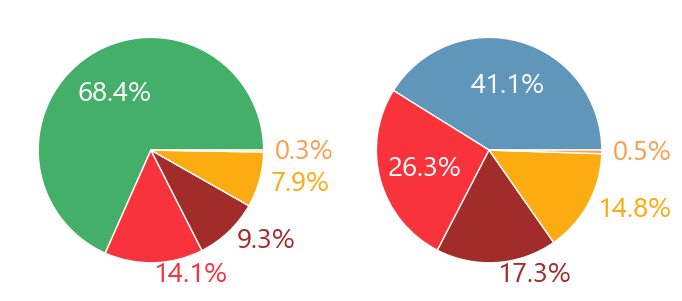

In [45]:
fig, ax = plt.subplots(1,2,figsize =(8, 16))
fontsize = 20
pctdistance = 0.6

label_in_h = [1,0,0,0,0]
label_in_l = [1,1,0,0,0]

labels0 = [('{:.1f}%').format(100*power/(P_tot_h)) for power in Power_h]

patches0, texts0, text0_in = ax[0].pie(Power_h, labels = labels0,  
                                    shadow=False, 
                                    startangle=0,   colors= colors_bar_h, autopct='%.1f%%', 
                                    wedgeprops={'linewidth': 1.0, 'edgecolor': 'white'},
                                    textprops={'fontsize': fontsize},normalize=True, pctdistance=pctdistance)
for i,t in enumerate(texts0):
    t.set_color(colors_bar_h[i])
    if label_in_h[i] == 1:
        t.set_text("")
for i,t in enumerate(text0_in):
    t.set_color("white")
    if label_in_h[i] == 0:
        t.set_text("")

labels1 = [('{:.1f}%').format(100*power/(P_tot_l))  for power in Power_l]
patches1, texts1,text1_in = ax[1].pie(Power_l, labels = labels1, 
                                    shadow=False, 
                                    startangle=0,   colors= colors_bar_l, autopct='%.1f%%', 
                                    wedgeprops={'linewidth': 1.0, 'edgecolor': 'white'},
                                    textprops={'fontsize': fontsize},normalize=True, pctdistance=pctdistance)
for i,t in enumerate(texts1):
    t.set_color(colors_bar_l[i])
    if label_in_l[i] == 1:
        t.set_text("")
for i,t in enumerate(text1_in):
    t.set_color("white")
    if label_in_l[i] == 0:
        t.set_text("")

